# PRÁCTICA MACHINE LEARNING

## Graph Classification with Graph Neural Networks. Dataset: IMDB-BINARY

Profesor: Francisco Escolano

Alumno: Nicolás Vives Vicente

La tarea más común para la clasificación de grafos es la **predicción de propiedades moleculares**, en la que las moléculas se representan como grafos, y la tarea puede consistir en inferir si una molécula inhibe la replicación del virus del VIH o no.

La Universidad Técnica de Dortmund ha recopilado una amplia gama de diferentes conjuntos de datos de clasificación de grafos, conocidos como [**TUDatasets**](https://chrsmrrs.github.io/datasets/), los cuales también son accesibles a través de [`torch_geometric.datasets.TUDataset`](https://pytorch-geometric.readthedocs.io/en/latest/modules/datasets.html#torch_geometric.datasets.TUDataset) en PyTorch Geometric.

En este notebook se estudia el **conjunto de datos IMDB-BINARY**:

## Librerías necesarias:

In [ ]:
# Librerías Estándar de Python
import os
import csv
import random
from collections import Counter

# Análisis de Datos, Grafos y Visualización
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# PyTorch
import torch
import torch.nn.functional as F
from torch.nn import Linear

# PyTorch Geometric (Utilidades)
import torch_geometric.data
from torch_geometric.utils import degree
import torch_geometric.transforms as T
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx, to_dense_batch, to_dense_adj

# PyTorch Geometric (Capas GNN y Pooling)
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool  # Global Mean Pooling
from torch_geometric.nn import global_add_pool   # Global Add Pooling
from torch_geometric.nn import global_max_pool   # Global Max Pooling

# Modelo Net
from torch_geometric.nn import dense_mincut_pool, DenseGraphConv

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Inspección del dataset:

In [ ]:
dataset = TUDataset(root='data/TUDataset', name='IMDB-BINARY')

grado_maximo_global = 0

for data in dataset:
    # edge_index[0] contiene todos los nodos de origen (source nodes).
    # degree() cuenta cuántas veces aparece cada nodo, lo que equivale a su grado.
    # le pasamos num_nodes por si hay nodos aislados (grado 0).
    d = degree(data.edge_index[0], num_nodes=data.num_nodes, dtype=torch.long)
    
    # buscamos el nodo con el grado más alto en este grafo en particular
    max_d_grafo = d.max().item()
    
    # actualizamos nuestro contador global si encontramos un grado mayor
    if max_d_grafo > grado_maximo_global:
        grado_maximo_global = max_d_grafo

print(f"El grado máximo en todo el dataset es: {grado_maximo_global}")

El grado máximo en todo el dataset es: 135


In [6]:
dataset = TUDataset(root='data/TUDataset', name='IMDB-BINARY', transform=T.OneHotDegree(max_degree=135))

print()
print(f'Dataset: {dataset}:')
print('====================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Extraemos las etiquetas (y) de cada grafo y las contamos
labels = [data.y.item() for data in dataset]
class_counts = Counter(labels)

print('====================')
print('Samples per class:')
for cls, count in sorted(class_counts.items()):
    print(f' - Class {cls}: {count}')
print('====================')

num_nodes_list = [data.num_nodes for data in dataset]

mean_nodes = np.mean(num_nodes_list)
min_nodes = np.min(num_nodes_list)
max_nodes = np.max(num_nodes_list)

print('Node statistics per molecule:')
print(f' - Mean nodes: {mean_nodes:.2f}')
print(f' - Min nodes: {min_nodes}')
print(f' - Max nodes: {max_nodes}')
print('====================')

data = dataset[0]  # Get the first graph object.

print()
print(data)
print('=============================================================')

# Gather some statistics about the first graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')


Dataset: IMDB-BINARY(1000):
Number of graphs: 1000
Number of features: 136
Number of classes: 2
Samples per class:
 - Class 0: 500
 - Class 1: 500
Node statistics per molecule:
 - Mean nodes: 19.77
 - Min nodes: 12
 - Max nodes: 136

Data(edge_index=[2, 146], y=[1], num_nodes=20, x=[20, 136])
Number of nodes: 20
Number of edges: 146
Average node degree: 7.30
Has isolated nodes: False
Has self-loops: False
Is undirected: True


El cambio fundamental respecto a los experimentos anteriores se encuentra en cómo se procesan los datos iniciales. Originalmente, este *dataset* no posee características innatas en los nodos (*node features*). Dado que las redes neuronales de grafos requieren obligatoriamente una matriz de características de entrada $x$ para operar, se han generado de forma sintética.

Para ello, se utiliza el módulo de transformaciones de `PyTorch Geometric`, cargando el conjunto con `T.OneHotDegree(max_degree=135)`. Al ser 135 el grado máximo detectado en todo el conjunto, esta transformación dota a cada nodo de un vector de características sintéticas de **136 dimensiones** (representando los grados del 0 al 135 mediante codificación *one-hot*).

* **Número total de grafos:** 1000
* **Características de nodo:** 136 (generadas artificialmente mediante el grado del nodo).
* **Número de clases:** 2 (clasificación binaria).
* **Distribución de clases:** Perfectamente equilibrada, con exactamente 500 muestras para la Clase 0 y 500 muestras para la Clase 1.

**Estadísticas de tamaño por red (grafo):**
* **Media de nodos:** 19.77
* **Rango de nodos:** De 12 (mínimo) a 136 (máximo).

Al examinar el primer objeto de grafo del conjunto (`Data(edge_index=[2, 146], x=[20, 136], y=[1], num_nodes=20)`), se observan sus propiedades exactas:

20 nodos (con vectores de características artificiales de 136 dimensiones) y 146 aristas, lo que arroja un grado promedio de nodo de 7.30.
Cuenta con exactamente una etiqueta de clasificación para el grafo completo ($y=[1]$).

Además, el análisis topológico de esta primera muestra revela propiedades estructurales clave de estas redes de colaboración:

* **No dirigido (*Is undirected: True*):** La relación de haber actuado juntos en una película es bidireccional.
* **Conectividad total (*Has isolated nodes: False*):** La estructura no presenta nodos aislados, asegurando que todos los actores forman parte de la topología principal de la red.
* **Sin bucles (*Has self-loops: False*):** No existen conexiones de un nodo consigo mismo.

Veamos un ejemplo de molécula perteneciente a cada una de las clases.

tensor([0])
tensor([1])


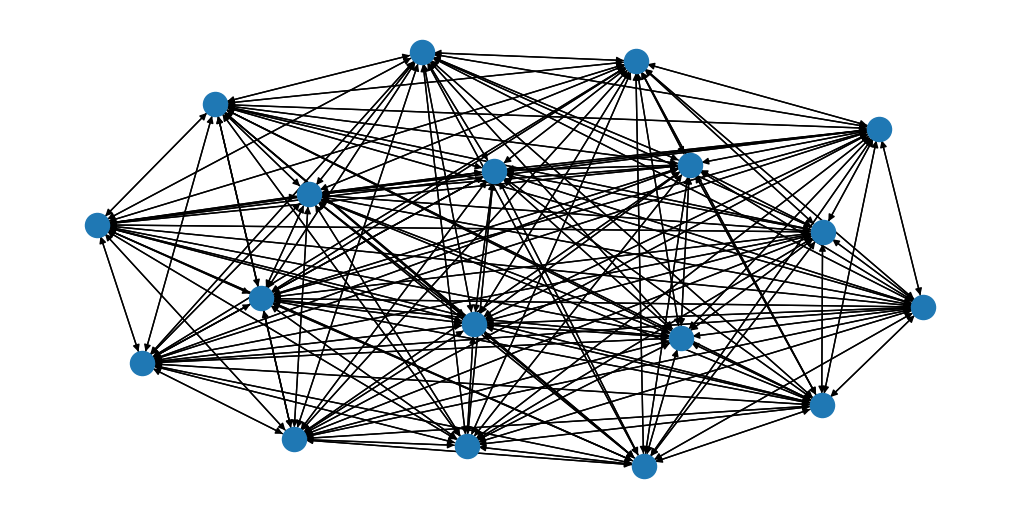

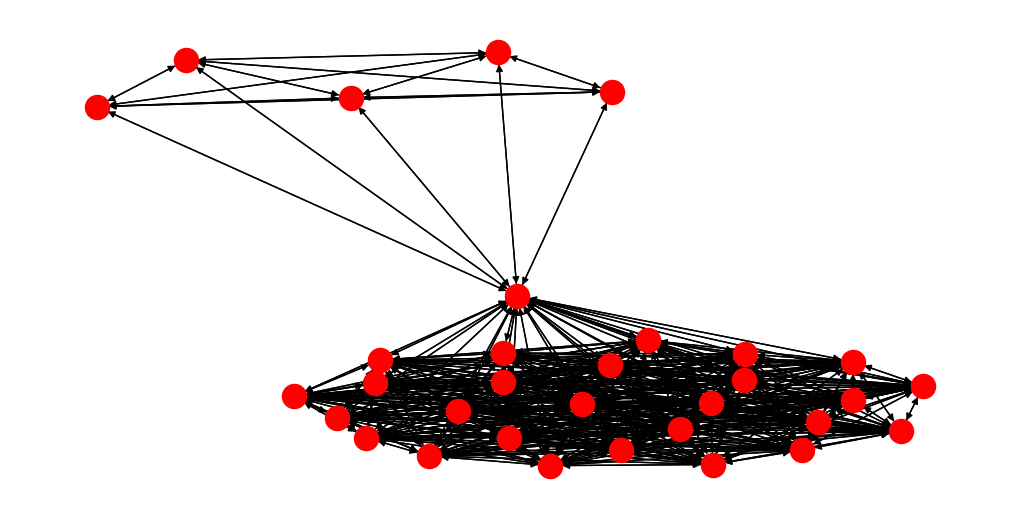

In [7]:
data = random.choice([t for t in dataset if t.y==0])
g = to_networkx(data)
plt.figure(figsize=(10, 5))
nx.draw(g)
print(data.y)

data = random.choice([t for t in dataset if t.y==1])
g = to_networkx(data)
plt.figure(figsize=(10, 5))
nx.draw(g,node_color='r')
print(data.y)

Antes de comenzar con el entrenamiento y evaluación de los modelos conviene mencionar que se han detectado algunos problemas en el código proporcionado para la práctica y se han solucionado de las siguientes formas:

- Cálculo Aislado del Espectro Laplaciano (Graph-by-Graph):

    - Problema: Calcular el Laplaciano sobre el batch completo genera un grafo enorme, con tantas componentes desconectadas como moléculas haya en el lote. Matemáticamente, esto produce un autovalor igual a cero por cada componente. Al seleccionar los $k$ primeros, estos ceros acaparan la selección, entregando a la red autovectores vacíos que hacen inútil la geometría espacial y disparan el coste computacional al operar sobre una matriz gigante.

    - Solución implementada: Se ha aplicado una estrategia de "divide y vencerás", modificando la función para que desempaquete el lote y calcule el Laplaciano molécula por molécula de forma estrictamente individual. Esto garantiza un único autovalor cero por grafo, permitiendo que el resto de los $k$ autovectores extraigan correctamente las auténticas frecuencias estructurales y formas tridimensionales, reduciendo además la complejidad computacional.

- Corrección del Bucle de Validación (DataLoaders y Reproducibilidad):

    - Problema: La evaluación de modelos (incluyendo la red base Net) estaba consumiendo DataLoaders instanciados globalmente al inicio del notebook. Esto provocaba que, aunque los modelos variaran sus pesos iniciales y por tanto sí daban resultados distintos, no se estaba respetando la semilla de reproducibilidad para la partición de datos en las distintas iteraciones.

    - Solución implementada: Se ha reestructurado el bucle principal de evaluación. Ahora, la división del dataset y la generación de los train_loader y test_loader se ejecutan internamente en cada iteración, garantizando que los datos de entrenamiento y prueba cambien respetando la partición de los datos según la semilla activa.

Funciones heredadas con las modificaciones aplicadas:

In [10]:
def compute_laplacian_eigenvectors_pytorch(data, k):
    # 1. Convert PyTorch Geometric graph to NetworkX graph
    g = to_networkx(data, to_undirected=True)

    # 2. Compute the normalized Laplacian matrix using NetworkX
    # networkx.normalized_laplacian_matrix returns a sparse matrix
    # Then we make it dense and compatible with numpy
    L = nx.normalized_laplacian_matrix(g).todense()

    # 3. Finding eigen values and eigen vectors
    e, evecs = np.linalg.eig(L)
    #e.shape, evecs.shape

    # 4. Sort eigenvectors
    # Sort them (both e's and evecs's) ascending
    idx =e.argsort()
    e = e[idx]
    evecs = evecs[:,idx]

    # 3. Convert the sparse Laplacian matrix to a dense PyTorch tensor
    # Convert to dense numpy array first, then to torch tensor
    evecs_torch = torch.tensor(np.real(evecs[:,:k]), dtype=torch.float32)

    return evecs_torch

# Train and test functions. Use k=0 when no spectral info
def train(model, train_loader, optimizer, k):
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for data in train_loader:  # Iterate in batches over the training dataset.
        optimizer.zero_grad()
        # Ensure all data components are on the correct device
        data.x = data.x.to(device)
        data.edge_index = data.edge_index.to(device)
        data.y = data.y.to(device)
        data.batch = data.batch.to(device)

        # MODIFICACIÓN
        if k > 0:
            evecs_list = []
            # Desempaquetamos el batch en grafos individuales
            for single_graph in data.to_data_list():
                # Calculamos el Laplaciano molécula por molécula
                evecs_single = compute_laplacian_eigenvectors_pytorch(single_graph, k=k)
                num_evecs = evecs_single.size(1)
                if num_evecs < k:
                    columnas_faltantes = k - num_evecs
                    # Rellenamos con ceros las columnas que faltan
                    evecs_single = F.pad(evecs_single, (0, columnas_faltantes, 0, 0), "constant", 0.0)
                
                evecs_list.append(evecs_single)
            
            # Volvemos a unir los resultados en un solo tensor y lo pasamos a la GPU
            evecs_torch = torch.cat(evecs_list, dim=0).to(device)
            # Concatenamos con las características originales
            data.x = torch.cat([data.x, evecs_torch], dim=1)
        # FIN MODIFICACIÓN

        # Pass data components to the model
        out = model(data.x, data.edge_index, data.batch)

        loss = criterion(out, data.y)  # Compute the loss.
        loss.backward()  # Derive gradients.
        optimizer.step()  # Update parameters based on gradients.

        total_loss += loss.item() * data.y.size(0)
        pred = out.argmax(dim=1)
        total_correct += (pred == data.y).sum().item()
        total_samples += data.y.size(0)

    return total_loss / total_samples, total_correct / total_samples

def test(model, loader, k):
    model.eval()
    total_correct = 0
    total_samples = 0
    total_loss = 0

    with torch.no_grad():
        for data in loader:  # Iterate in batches over the training/test dataset.
            # Ensure all data components are on the correct device
            data.x = data.x.to(device)
            data.edge_index = data.edge_index.to(device)
            data.y = data.y.to(device)
            data.batch = data.batch.to(device)

        # MODIFICACIÓN
            if k > 0:
                evecs_list = []
                for single_graph in data.to_data_list():
                    evecs_single = compute_laplacian_eigenvectors_pytorch(single_graph, k=k)
                    num_evecs = evecs_single.size(1)
                    if num_evecs < k:
                        columnas_faltantes = k - num_evecs
                        # Rellenamos con ceros las columnas que faltan
                        evecs_single = F.pad(evecs_single, (0, columnas_faltantes, 0, 0), "constant", 0.0)
                    
                    evecs_list.append(evecs_single)
                
                evecs_torch = torch.cat(evecs_list, dim=0).to(device)
                data.x = torch.cat([data.x, evecs_torch], dim=1)
        # FIN MODIFICACIÓN

            out = model(data.x, data.edge_index, data.batch)

            loss = criterion(out, data.y) # Compute the loss.
            total_loss += loss.item() * data.y.size(0)

            pred = out.argmax(dim=1)  # Use the class with highest probability.
            total_correct += int((pred == data.y).sum())  # Check against ground-truth labels.
            total_samples += data.y.size(0)

    return total_loss / total_samples, total_correct / total_samples

def split(dataset, seed):
  torch.manual_seed(seed)
  dataset = dataset.shuffle()

  # Get 25% approx per test
  split_idx = int(len(dataset) * 0.75)
  print("split idx", split_idx)

  train_dataset = dataset[:split_idx]
  test_dataset = dataset[split_idx:]

  #print(f'Number of training graphs: {len(train_dataset)}')
  #print(f'Number of test graphs: {len(test_dataset)}')
  return train_dataset, test_dataset

## Experimento 1: Evaluación de Arquitecturas Base

Comenzamos el análisis del dataset **IMDB-BINARY** estableciendo las líneas base. El objetivo es evaluar el comportamiento de las redes de clasificación de grafos y el impacto de la información geométrica al clasificar las estructuras en géneros cinematográficos (Acción o Romance).

En este primer experimento se utilizará la configuración predeterminada del *notebook*, adaptada a las nuevas dimensiones del problema:

| Hiperparámetro | Valor |
| :--- | :--- |
| Canales Ocultos (*Hidden Channels*) | 64 |
| Número de Capas Convolucionales | 3 |
| Resolución Espectral ($k$) | 4 |
| Tipo de Agregación (*Pooling*) | Global Mean Pool |

Las arquitecturas se han adaptado específicamente para gestionar la alta dimensionalidad de entrada generada por las características sintéticas:

1. **GCN (Línea base):** Su primera capa recibe **136 dimensiones**, correspondientes a la codificación *one-hot* del grado de los nodos. Tras 3 capas de 64 canales, finaliza en una capa lineal que emite una predicción sobre **2 clases posibles** e ignora la topología espacial global.
2. **GCNEig (Fusión temprana):** Añade la codificación espectral desde el inicio. Su entrada se amplía a **140 dimensiones** (136 sintéticas + 4 espaciales). La red procesa simultáneamente el grado del nodo y su posición global en la red social desde el primer salto de mensaje.
3. **GCNEigDecoupled (Fusión tardía):** Emplea vías de procesamiento paralelas. Analiza el vector de grados en la rama convolucional (entrada de 136 dimensiones) y la geometría espacial en una proyección lineal independiente (proyectando los 4 autovectores a 32 canales). Ambas señales se concatenan en la profundidad de la red antes de emitir la clasificación binaria final.

In [11]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=64,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(136, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(140, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(136, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


In [12]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Mean Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_IMDB_BINARY.csv")
        with open("resultados_IMDB_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_IMDB_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCN
Random State 12345  in the iteration 0
split idx 750
Epoch: 001, Loss: 0.62998, Train Acc: 0.66267
Epoch: 002, Loss: 0.51912, Train Acc: 0.74667
Epoch: 003, Loss: 0.51545, Train Acc: 0.73333
Epoch: 004, Loss: 0.48430, Train Acc: 0.74133
Epoch: 005, Loss: 0.49292, Train Acc: 0.75467
Epoch: 006, Loss: 0.48962, Train Acc: 0.74267
Epoch: 007, Loss: 0.47867, Train Acc: 0.75067
Epoch: 008, Loss: 0.47276, Train Acc: 0.74133
Epoch: 009, Loss: 0.47035, Train Acc: 0.75067
Epoch: 010, Loss: 0.46817, Train Acc: 0.74800
Epoch: 011, Loss: 0.45793, Train Acc: 0.77067
Epoch: 012, Loss: 0.45142, Train Acc: 0.77067
Epoch: 013, Loss: 0.47576, Train Acc: 0.73733
Epoch: 014, Loss: 0.45650, Train Acc: 0.76267
Epoch: 015, Loss: 0.45114, Train Acc: 0.77333
Epoch: 016, Loss: 0.45302, Train Acc: 0.77067
Epoch: 017, Loss: 0.43512, Train Acc: 0.78533
Epoch: 018, Loss: 0.43064, Train Acc: 0.77867
Epoch: 019, Loss: 0.42378, Train Acc: 0.78133
Epoch: 020, Loss: 0.42140, Train Acc: 0.77733
Epo

Tras evaluar la configuración predeterminada con agregación por promedio, se obtuvieron las siguientes métricas de rendimiento:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 3 | Mean | 0 | $82.51 \pm 1.82$ | $72.28 \pm 3.14$ |
| **GCNEig** | 64 | 3 | Mean | 4 | $88.75 \pm 0.92$ | $69.68 \pm 2.39$ |
| **GCNEigDecoupled** | 64 | 3 | Mean | 4 | $83.80 \pm 1.30$ | $\mathbf{73.68 \pm 1.79}$ |

Al observar las métricas, queda de manifiesto que la estrategia utilizada para procesar e integrar la información marca una diferencia drástica en el rendimiento:

* El modelo `GCNEig` sufre una caída notable en validación (69.68%) respecto al modelo base `GCN` (72.28%). No obstante, su precisión en entrenamiento se dispara casi al 89%. Esto evidencia un claro caso de sobreajuste (*overfitting*): concatenar directamente las 136 características sintéticas con los 4 autovectores en la entrada genera un espacio tan ruidoso que la red opta por memorizar los grafos en lugar de aprender patrones generales.
* Por el contrario, la arquitectura de fusión tardía maneja esta alta dimensionalidad a la perfección. Al procesar el vector de grados y la geometría estructural por vías independientes antes de combinarlos, logra el mejor resultado en validación (**73.68%**) y asegura la varianza más baja de todo el experimento ($\pm 1.79$).

A pesar de las buenas métricas del modelo desacoplado, aplicar un promedio global (`Global Mean Pool`) en una red de colaboración social puede estar diluyendo el impacto de los nodos clave o actores centrales. Esto nos motiva a explorar nuevas dinámicas de agregación:

1. **Experimento 2 (`Global Max Pool`):** Evaluaremos el impacto de aislar la activación más alta de la red. La hipótesis es que capturar la señal del actor más influyente o central puede ser determinante para identificar el género de la película.
2. **Experimento 3 (`Global Add Pool`):** Evaluaremos la agregación por suma. Dado que los grafos representan redes de actores, acumular las características podría ser útil para representar el "volumen o densidad total" de la red, el cual podría variar entre películas de acción y romance.

## Experimento 2: Impacto de `Global Max Pool`

En este experimento se modifica la capa de agregación (*readout layer*) tras observar que el promedio (`Mean Pool`) podría estar restando peso a los elementos más determinantes.

Las redes sociales y de colaboración cinematográfica se estructuran habitualmente en torno a unos pocos nodos con una centralidad y conectividad extremadamente altas (los actores protagonistas o directores estrella). 

* Utilizar un promedio pondera a todos los miembros del reparto por igual. En grafos de redes sociales, esto tiende a diluir el impacto de las figuras clave entre la gran cantidad de actores secundarios o de reparto menor, camuflando patrones determinantes.
* La implementación de `Global Max Pool` actúa como un selector de características extremas. En lugar de mitigar las señales, esta operación matemática conserva el valor de activación más alto para cada canal a lo largo de todo el grafo. En el contexto de IMDB-BINARY, esto permite a la red identificar y retener las propiedades de los actores centrales, cuya influencia estructural e interconexiones suelen ser el factor diferencial para discriminar el género de la película.

In [13]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=64,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(136, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(140, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(136, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Max Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_IMDB_BINARY.csv")
        with open("resultados_IMDB_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_IMDB_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCN
Random State 12345  in the iteration 0
split idx 750
Epoch: 001, Loss: 0.63311, Train Acc: 0.66133
Epoch: 002, Loss: 0.53130, Train Acc: 0.74000
Epoch: 003, Loss: 0.52077, Train Acc: 0.73467
Epoch: 004, Loss: 0.48697, Train Acc: 0.73600
Epoch: 005, Loss: 0.49077, Train Acc: 0.74533
Epoch: 006, Loss: 0.47991, Train Acc: 0.73600
Epoch: 007, Loss: 0.47336, Train Acc: 0.76000
Epoch: 008, Loss: 0.46777, Train Acc: 0.74533
Epoch: 009, Loss: 0.46431, Train Acc: 0.75467
Epoch: 010, Loss: 0.45622, Train Acc: 0.75467
Epoch: 011, Loss: 0.44482, Train Acc: 0.77467
Epoch: 012, Loss: 0.43832, Train Acc: 0.76533
Epoch: 013, Loss: 0.46236, Train Acc: 0.76267
Epoch: 014, Loss: 0.44162, Train Acc: 0.75467
Epoch: 015, Loss: 0.43394, Train Acc: 0.78400
Epoch: 016, Loss: 0.45514, Train Acc: 0.77067
Epoch: 017, Loss: 0.43314, Train Acc: 0.78133
Epoch: 018, Loss: 0.43127, Train Acc: 0.78400
Epoch: 019, Loss: 0.42532, Train Acc: 0.78933
Epoch: 020, Loss: 0.41584, Train Acc: 0.78933
Epo

Las métricas de rendimiento obtenidas tras aplicar la agregación por características máximas se detallan a continuación:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 3 | Max | 0 | $82.60 \pm 1.74$ | $72.88 \pm 2.17$ |
| **GCNEig** | 64 | 3 | Max | 4 | $88.12 \pm 1.72$ | $70.80 \pm 2.64$ |
| **GCNEigDec.** | 64 | 3 | Max | 4 | $85.37 \pm 0.98$ | $72.52 \pm 2.33$ |

Al analizar las métricas, observamos que aislar las características máximas produce resultados mixtos dependiendo de la naturaleza de la arquitectura:

* Tanto el modelo base como el de fusión temprana experimentan una ligera mejoría en validación en comparación con el experimento anterior (`Mean Pool`), alcanzando un 72.88% y un 70.80% respectivamente. Identificar al "actor central" beneficia a estas estructuras.
* Por el contrario, nuestro claro ganador previo sufre un retroceso, bajando su precisión en validación al 72.52% (desde el 73.68% que registraba con promedio). Para esta arquitectura en específico, ignorar la información agregada del resto del reparto y quedarse únicamente con el rasgo máximo termina por empobrecer la riqueza de las predicciones.
* El problema más crítico detectado sigue siendo el severo *overfitting*. Absolutamente todos los modelos presentan una brecha de entre 10 y 17 puntos porcentuales entre la precisión de *Train* y la de *Test*. La red continúa memorizando estructuras específicas en lugar de generalizar patrones abstractos asociados al género cinematográfico.

Es probable que las películas de acción y las de romance difieran en el **volumen total de su reparto** y la densidad de conexiones. Esto motiva el **Experimento 3**, donde evaluaremos la agregación mediante **`Global Add Pool`**. Al acumular y sumar todas las características de los nodos, esperamos proporcionar a la red una magnitud y densidad clara de la red social, facilitando una discriminación mayor del género de la película.

## Experimento 3: Impacto de `Global Add Pool`

Tras probar el promedio (`Mean Pool`) y el máximo (`Max Pool`) y no lograr reducir el sobreajuste que sufre la red, en este experimento buscamos comprobar si el "volumen total" de la red aporta información valiosa.

En el ámbito cinematográfico, sumar las características de todos los nodos proporciona a la red una estimación de cómo de conectada y grande es la red del actor principal, lo cual podría ser un factor discriminativo clave entre una película de acción (quizás con grupos más interconectados) y una de romance.

In [15]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=64,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(136, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(140, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(136, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
POOLING_TYPE = 'Global Add Pool'
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):
    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_IMDB_BINARY.csv")
        with open("resultados_IMDB_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_IMDB_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCN
Random State 12345  in the iteration 0
split idx 750
Epoch: 001, Loss: 0.65721, Train Acc: 0.65600
Epoch: 002, Loss: 0.51788, Train Acc: 0.72400
Epoch: 003, Loss: 0.50689, Train Acc: 0.72933
Epoch: 004, Loss: 0.47786, Train Acc: 0.74933
Epoch: 005, Loss: 0.49134, Train Acc: 0.74933
Epoch: 006, Loss: 0.47674, Train Acc: 0.75467
Epoch: 007, Loss: 0.47127, Train Acc: 0.75467
Epoch: 008, Loss: 0.47443, Train Acc: 0.74800
Epoch: 009, Loss: 0.45118, Train Acc: 0.76800
Epoch: 010, Loss: 0.47419, Train Acc: 0.72533
Epoch: 011, Loss: 0.44649, Train Acc: 0.76933
Epoch: 012, Loss: 0.44946, Train Acc: 0.77733
Epoch: 013, Loss: 0.46047, Train Acc: 0.74133
Epoch: 014, Loss: 0.44732, Train Acc: 0.76667
Epoch: 015, Loss: 0.44177, Train Acc: 0.77600
Epoch: 016, Loss: 0.43308, Train Acc: 0.77333
Epoch: 017, Loss: 0.42321, Train Acc: 0.76933
Epoch: 018, Loss: 0.43410, Train Acc: 0.75733
Epoch: 019, Loss: 0.43307, Train Acc: 0.77867
Epoch: 020, Loss: 0.40100, Train Acc: 0.78933
Epo

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 3 | Add | 0 | 83.13 $\pm$ 2.16 | 72.92 $\pm$ 2.32 |
| **GCNEig** | 64 | 3 | Add | 4 | 88.79 $\pm$ 1.82 | 69.52 $\pm$ 3.03 |
| **GCNEigDec.** | 64 | 3 | Add | 4 | 84.95 $\pm$ 1.12 | **73.20 $\pm$ 2.60** |

Sumar las características no supera globalmente al promedio, pero proporciona datos clave:

* **GCN:** Mejora ligeramente (72.92%). Sumar los grados ayuda al modelo ciego a estimar mejor el tamaño total de la red.
* **GCNEig:** Mantiene un *overfitting* extremo (88.79% en *Train* vs 69.52% en *Test*), confirmando que la fusión temprana de 136 variables *one-hot* y 4 autovectores fuerza la memorización.
* **GCNEigDecoupled:** Se recupera (73.20%) frente a `Max Pool`, pero no logra superar el 73.68% obtenido con `Mean Pool` en el primer experimento.

El problema principal persiste: una **brecha de sobreajuste de 10 a 19 puntos**. Al tratar un problema binario con características sintéticas, 64 canales resultan en una sobre-parametrización excesiva. 

El **Experimento 4** reducirá los canales ocultos (*hidden channels*) para asfixiar la memorización. Para ello, cada modelo mantendrá la capa de agregación que mejor rendimiento le ha dado:
* **GCN:** `Global Add Pool`
* **GCNEig:** `Global Max Pool`
* **GCNEigDecoupled:** `Global Mean Pool`

## Experimento 4: Reducción de *Hidden Channels*

Para combatir el severo sobreajuste detectado, evaluaremos el impacto de limitar la capacidad latente de la red reduciendo los canales ocultos (*hidden channels*) de **64 a 32**. 

A partir de este punto, cada arquitectura utilizará exclusivamente la capa de agregación (*readout layer*) que mejor rendimiento le ha otorgado en los experimentos previos:
* **GCN:** `Add Pool`
* **GCNEig:** `Max Pool`
* **GCNEigDecoupled:** `Mean Pool`

El modelo sufre un claro *overfitting* a causa de una sobre-parametrización. Proyectar las 136 características sintéticas de entrada (*one-hot degree*) sobre 64 canales genera una matriz de pesos masiva, otorgando a la red la libertad de memorizar el conjunto de entrenamiento.

Reducir el espacio latente a **32 canales** actúa como una regularización directa. Al crear este cuello de botella dimensional, forzamos a la red a comprimir la información, descartar el ruido topológico y extraer únicamente los patrones estructurales que definen la diferencia entre una película de acción y una de romance.

In [18]:
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, seed):
        super(GCN, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_add_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCN(hidden_channels=32,seed=12345)
print(model)

class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=32, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=32, seed=12345, k=4)
print(model)

GCN(
  (conv1): GCNConv(136, 32)
  (conv2): GCNConv(32, 32)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=2, bias=True)
)
GCNEig(
  (conv1): GCNConv(140, 32)
  (conv2): GCNConv(32, 32)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(136, 32)
  (conv2): GCNConv(32, 16)
  (conv3): GCNConv(32, 32)
  (lin): Linear(in_features=32, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=16, bias=True)
)


In [ ]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 32
k_val = 4

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCN, GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):

    if j == 0:
        POOLING_TYPE = 'Global Add Pool'
    elif j == 1:
        POOLING_TYPE = 'Global Max Pool'
    elif j == 2:
        POOLING_TYPE = 'Global Mean Pool'

    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_IMDB_BINARY.csv")
        with open("resultados_IMDB_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_IMDB_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCN
Random State 12345  in the iteration 0
split idx 750
Epoch: 001, Loss: 0.66192, Train Acc: 0.62133
Epoch: 002, Loss: 0.52257, Train Acc: 0.73200
Epoch: 003, Loss: 0.52422, Train Acc: 0.73333
Epoch: 004, Loss: 0.49519, Train Acc: 0.73600
Epoch: 005, Loss: 0.48163, Train Acc: 0.74400
Epoch: 006, Loss: 0.48311, Train Acc: 0.74133
Epoch: 007, Loss: 0.45859, Train Acc: 0.75733
Epoch: 008, Loss: 0.45800, Train Acc: 0.76800
Epoch: 009, Loss: 0.45935, Train Acc: 0.76133
Epoch: 010, Loss: 0.47131, Train Acc: 0.75333
Epoch: 011, Loss: 0.45482, Train Acc: 0.75200
Epoch: 012, Loss: 0.44237, Train Acc: 0.76800
Epoch: 013, Loss: 0.43078, Train Acc: 0.76000
Epoch: 014, Loss: 0.43653, Train Acc: 0.76667
Epoch: 015, Loss: 0.42605, Train Acc: 0.77200
Epoch: 016, Loss: 0.44157, Train Acc: 0.76800
Epoch: 017, Loss: 0.43592, Train Acc: 0.76400
Epoch: 018, Loss: 0.41880, Train Acc: 0.77600
Epoch: 019, Loss: 0.42931, Train Acc: 0.77467
Epoch: 020, Loss: 0.42956, Train Acc: 0.76400
Epo

Las métricas obtenidas tras asfixiar la capacidad de las redes a 32 canales se presentan a continuación:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 32 | 3 | Add | 0 | $84.36 \pm 2.18$ | $72.64 \pm 3.33$ |
| **GCNEig** | 32 | 3 | Max | 4 | $87.68 \pm 1.91$ | $71.20 \pm 3.39$ |
| **GCNEigDec.** | 32 | 3 | Mean | 4 | $83.02 \pm 1.40$ | $71.48 \pm 2.65$ |

Los resultados demuestran que, a diferencia de lo observado en otros conjuntos de datos, reducir la capacidad de representación resulta contraproducente para IMDB-BINARY:

* Al limitar la memoria de la red a 32 canales, todos los modelos sufren un descenso en su precisión de validación respecto a sus mejores marcas previas (con 64 canales). Destaca la caída del modelo `GCNEigDecoupled`, que pasa del 73.68% (Experimento 1) a un 71.48%.
* Esta asfixia dimensional no logra solventar el problema principal. El *overfitting* sigue siendo notable, manteniendo precisiones de entrenamiento entre el 83% y el 87%.

A la luz de estos resultados empíricos, **descartamos la configuración de 32 dimensiones** y restauramos los **64 canales ocultos** como el estándar óptimo de capacidad para este conjunto de datos. Las funciones de agregación personalizadas para cada modelo se mantienen intactas.

Con esta arquitectura base consolidada, el **Experimento 5** se centrará en evaluar la influencia de la topología de entrada. Variaremos el número de autovectores del Laplaciano ($k \in \{6, 8, 10\}$) para comprobar si proporcionar un información estructural de mayor resolución ayuda a la red a superar, por fin, la barrera del 73% de precisión en validación.

## Experimento 5: *Positional Encoding* ($k$)

Para concluir la fase de experimentación, y habiendo consolidado el uso de 64 canales ocultos (*hidden channels*) junto con la capa de agregación óptima para cada arquitectura, evaluaremos el impacto de aumentar la resolución espacial variando el número de autovectores del Laplaciano ($k \in \{6, 8, 10\}$).

En el contexto de redes sociales cinematográficas, una resolución base de $k=4$ proporciona una visión general útil, pero podría resultar insuficiente para identificar micro-comunidades específicas. Incrementar el parámetro a $k=6, 8, 10$ busca dotar a la red de coordenadas espaciales con una mayor densidad de información estructural. 

En teoría, esta mayor resolución debería permitir a los modelos espectrales localizar con precisión aquellas agrupaciones clave de actores que dictaminan si la red de colaboración pertenece a una producción de acción o de romance.

Debido al tamaño del conjunto de datos que implica un mayor tiempo de ejecución, lo haremos en celdas separadas para realizar cortafuegos.

In [24]:
class GCNEig(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEig, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features + k, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Obtain node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)
        # 2. Readout layer
        x = global_max_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEig(hidden_channels=64, seed=12345, k=4)
print(model)

class GCNEigDecoupled(torch.nn.Module):
    def __init__(self, hidden_channels,seed, k):
        super(GCNEigDecoupled, self).__init__()
        torch.manual_seed(seed)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)
        self.lin2 = Linear(k, hidden_channels // 2)
        self.k = k # Store k for use in forward

    def forward(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        # Assuming the input x has original features first, then PE
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)


        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier (This comment is from the original notebook, it should be 4.)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)

        return x

    def get_embeddings(self, x, edge_index, batch):
        # 1. Decouple x into x_features and PE_features
        num_orig_features = dataset.num_node_features # Get the original number of node features
        x_features = x[:, :num_orig_features]
        PE_features = x[:, num_orig_features:]

        # 2. Obtain node embeddings using x_features
        x = self.conv1(x_features, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()

        # Process PE_features with lin2
        PE = self.lin2(PE_features)
        PE = PE.relu()

        # Concatenate processed x and PE for the next conv layer
        x = self.conv3(torch.cat([x, PE], dim=1), edge_index)

        # 2. Readout layer (This comment is from the original notebook, it should be 3.)
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]
        return x

model = GCNEigDecoupled(hidden_channels=64, seed=12345, k=4)
print(model)

GCNEig(
  (conv1): GCNConv(140, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)
GCNEigDecoupled(
  (conv1): GCNConv(136, 64)
  (conv2): GCNConv(64, 32)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
  (lin2): Linear(in_features=4, out_features=32, bias=True)
)


#### *k = 6*

In [25]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 6

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):

    if j == 0:
        POOLING_TYPE = 'Global Max Pool'
    elif j == 1:
        POOLING_TYPE = 'Global Mean Pool'

    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_IMDB_BINARY.csv")
        with open("resultados_IMDB_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_IMDB_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCNEig
Random State 12345  in the iteration 0
split idx 750
Epoch: 001, Loss: 0.64546, Train Acc: 0.61200
Epoch: 002, Loss: 0.54716, Train Acc: 0.70533
Epoch: 003, Loss: 0.51464, Train Acc: 0.73600
Epoch: 004, Loss: 0.48275, Train Acc: 0.73733
Epoch: 005, Loss: 0.47985, Train Acc: 0.75333
Epoch: 006, Loss: 0.47384, Train Acc: 0.76800
Epoch: 007, Loss: 0.45791, Train Acc: 0.75733
Epoch: 008, Loss: 0.44231, Train Acc: 0.79067
Epoch: 009, Loss: 0.44011, Train Acc: 0.78533
Epoch: 010, Loss: 0.43596, Train Acc: 0.79200
Epoch: 011, Loss: 0.42727, Train Acc: 0.79200
Epoch: 012, Loss: 0.43456, Train Acc: 0.77600
Epoch: 013, Loss: 0.43022, Train Acc: 0.77333
Epoch: 014, Loss: 0.41055, Train Acc: 0.79467
Epoch: 015, Loss: 0.42193, Train Acc: 0.78400
Epoch: 016, Loss: 0.38380, Train Acc: 0.80933
Epoch: 017, Loss: 0.38371, Train Acc: 0.80400
Epoch: 018, Loss: 0.39199, Train Acc: 0.79733
Epoch: 019, Loss: 0.37307, Train Acc: 0.82933
Epoch: 020, Loss: 0.36873, Train Acc: 0.81333


#### *k = 8*

In [26]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 8

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):

    if j == 0:
        POOLING_TYPE = 'Global Max Pool'
    elif j == 1:
        POOLING_TYPE = 'Global Mean Pool'

    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_IMDB_BINARY.csv")
        with open("resultados_IMDB_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_IMDB_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCNEig
Random State 12345  in the iteration 0
split idx 750
Epoch: 001, Loss: 0.63186, Train Acc: 0.61067
Epoch: 002, Loss: 0.55557, Train Acc: 0.71600
Epoch: 003, Loss: 0.52225, Train Acc: 0.73200
Epoch: 004, Loss: 0.50341, Train Acc: 0.74800
Epoch: 005, Loss: 0.49597, Train Acc: 0.74400
Epoch: 006, Loss: 0.47684, Train Acc: 0.74267
Epoch: 007, Loss: 0.46251, Train Acc: 0.76800
Epoch: 008, Loss: 0.46433, Train Acc: 0.76133
Epoch: 009, Loss: 0.45028, Train Acc: 0.77733
Epoch: 010, Loss: 0.44030, Train Acc: 0.77333
Epoch: 011, Loss: 0.44733, Train Acc: 0.78133
Epoch: 012, Loss: 0.43482, Train Acc: 0.78667
Epoch: 013, Loss: 0.41350, Train Acc: 0.79867
Epoch: 014, Loss: 0.41373, Train Acc: 0.79333
Epoch: 015, Loss: 0.39340, Train Acc: 0.80933
Epoch: 016, Loss: 0.41435, Train Acc: 0.78667
Epoch: 017, Loss: 0.39797, Train Acc: 0.79333
Epoch: 018, Loss: 0.38429, Train Acc: 0.81733
Epoch: 019, Loss: 0.38416, Train Acc: 0.80400
Epoch: 020, Loss: 0.37596, Train Acc: 0.81200


#### *k = 10*

In [29]:
# Seeds for the random split. This allows us to reproduce the results.
RandList = [12345, 423456, 643451, 543452, 743456, 4734510, 654321, 124321, 945321, 784328]
# This allows us to run the code on the GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Define common hidden_channels and k for models that use them
hidden_channels_val = 64
k_val = 10

# Solo para registrar en el CSV, hay que cambiar la red manualmente.
NUM_LAYERS = 3

# Here you can add models to train and test (include your own models)
models = [GCNEig, GCNEigDecoupled] # List of model classes

# Define the criterion (loss function)
criterion = torch.nn.CrossEntropyLoss()

global_results = []
global_best_models = []

for j in range(len(models)):

    if j == 0:
        POOLING_TYPE = 'Global Max Pool'
    elif j == 1:
        POOLING_TYPE = 'Global Mean Pool'

    ExperimentResult = []
    best_model = None
    current_model_class = models[j]

    print(f"Training Model: {current_model_class.__name__}")

    # Determine k for the current model. This logic needs to be inside the inner loop for each random state.
    # The `k` argument for compute_laplacian_eigenvectors_pytorch is also here.

    for i in range(10):
        print("Random State", RandList[i]," in the iteration",i)
        current_seed = RandList[i]
        # Split
        train_dataset, test_dataset = split(dataset, current_seed)
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False) # MODIFICACIÓN: Falataba crear cada uno de los loaders, se estaba pasando el inicial todo el rato

        # Instantiate model based on its class and its required arguments
        if current_model_class == GCN:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed).to(device)
            k_for_laplacian = 0 # GCN does not use PE
        elif current_model_class == GCNEig:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == GCNEigDecoupled:
            model = current_model_class(hidden_channels=hidden_channels_val, seed=current_seed, k=k_val).to(device)
            k_for_laplacian = k_val
        elif current_model_class == Net: # Net model uses in_channels, out_channels directly
            model = current_model_class(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)
            k_for_laplacian = 0 # Net (MinCut) model processes x directly, not expecting external PE concatenation in this specific forward method.
                                # If Net's forward was designed to take PE, k_for_laplacian would be adjusted.

        optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        for epoch in range(1, 101):
            # The `train` function now receives the model object directly
            loss, acc_train = train(model, train_loader, optimizer, k=k_for_laplacian)
            print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

        # The `test` function also receives the model object directly
        test_loss, acc = test(model, test_loader, k=k_for_laplacian)
        print('Test Accuracy: {:.5f}'.format(acc))

        # Save the best model over the 10 runs
        if best_model is None or acc > best_model[1]:
            best_model = [model, acc]
        ExperimentResult.append(acc)

        file_exists = os.path.isfile("resultados_IMDB_BINARY.csv")
        with open("resultados_IMDB_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                # Escribimos las cabeceras solo la primera vez que se crea el archivo
                writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
            
            # Vamos a guardar el último accuracy de entrenamiento en el csv para valorar el overfitting.
            acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
            acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
            # Escribimos los datos específicos de esta única ejecución
            writer.writerow([current_model_class.__name__, i, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, acc_train_formatted, acc_test_formatted, "", ""])


    mean_acc = np.mean(ExperimentResult) * 100
    std_acc = np.std(ExperimentResult) * 100

    mean_formatted = f"{mean_acc:.2f}".replace('.', ',')
    std_formatted = f"{std_acc:.2f}".replace('.', ',')

    with open("resultados_IMDB_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        # Escribimos la línea de resumen. Las precisiones individuales van vacías.
        writer.writerow([current_model_class.__name__, "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_laplacian, "", "", mean_formatted, std_formatted])

    print(current_model_class.__name__) # Name of the model
    print('{} +- {}'.format(mean_acc, std_acc))
    global_results.append(ExperimentResult.copy())
    global_best_models.append(best_model.copy())

cpu
Training Model: GCNEig
Random State 12345  in the iteration 0
split idx 750
Epoch: 001, Loss: 0.63127, Train Acc: 0.64267
Epoch: 002, Loss: 0.54433, Train Acc: 0.70800
Epoch: 003, Loss: 0.50892, Train Acc: 0.74800
Epoch: 004, Loss: 0.50207, Train Acc: 0.74800
Epoch: 005, Loss: 0.47910, Train Acc: 0.75467
Epoch: 006, Loss: 0.47938, Train Acc: 0.75333
Epoch: 007, Loss: 0.46863, Train Acc: 0.76400
Epoch: 008, Loss: 0.47192, Train Acc: 0.74533
Epoch: 009, Loss: 0.46399, Train Acc: 0.75733
Epoch: 010, Loss: 0.45676, Train Acc: 0.76533
Epoch: 011, Loss: 0.42988, Train Acc: 0.77467
Epoch: 012, Loss: 0.42316, Train Acc: 0.77467
Epoch: 013, Loss: 0.43997, Train Acc: 0.78533
Epoch: 014, Loss: 0.41237, Train Acc: 0.78667
Epoch: 015, Loss: 0.41635, Train Acc: 0.79600
Epoch: 016, Loss: 0.40314, Train Acc: 0.79867
Epoch: 017, Loss: 0.38785, Train Acc: 0.80667
Epoch: 018, Loss: 0.39464, Train Acc: 0.78933
Epoch: 019, Loss: 0.37326, Train Acc: 0.82000
Epoch: 020, Loss: 0.38295, Train Acc: 0.80133


Las métricas obtenidas tras aumentar la resolución espectral se presentan a continuación *(se omite el modelo base `GCN` ya que no utiliza este hiperparámetro)*:

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Configuración: $k = 6$** | | | | | | |
| **GCNEig** | 64 | 3 | Max | 6 | $87.81 \pm 1.67$ | $70.72 \pm 2.21$ |
| **GCNEigDec.** | 64 | 3 | Mean | 6 | $83.09 \pm 1.01$ | $71.20 \pm 2.55$ |
| **Configuración: $k = 8$** | | | | | | |
| **GCNEig** | 64 | 3 | Max | 8 | $88.19 \pm 1.58$ | $71.92 \pm 2.44$ |
| **GCNEigDec.** | 64 | 3 | Mean | 8 | $84.27 \pm 1.31$ | $73.24 \pm 2.70$ |
| **Configuración: $k = 10$** | | | | | | |
| **GCNEig** | 64 | 3 | Max | 10 | $88.57 \pm 1.52$ | $70.68 \pm 2.42$ |
| **GCNEigDec.** | 64 | 3 | Mean | 10 | $85.07 \pm 1.55$ | $72.00 \pm 2.94$ |

Incrementar la información geométrica en este conjunto de datos no logra superar el rendimiento de nuestra línea base inicial:

* **Memorización en `GCNEig`:** Aumentar la resolución no estabiliza la validación (fluctúa entre 70% y 71.92%). Simultáneamente, la precisión en entrenamiento mantiene una tendencia al alza (alcanzando 88.57% con $k=10$). El modelo utiliza el exceso de detalle topológico para memorizar los grafos en lugar de aprender características generalizables.
* **Límite en `GCNEigDecoupled`:** Esta arquitectura maneja mejor la alta resolución, con un pico de 73.24% en validación con $k=8$. Sin embargo, no logra batir su marca inicial (73.68% con $k=4$). Al forzar la entrada a $k=10$, el sobreajuste vuelve a dispararse (85% en entrenamiento) y la validación decae.

Proporcionar demasiados detalles espaciales termina forzando al modelo al sobreajuste. Considerando las limitaciones computacionales y la incapacidad de superar la marca inicial, establecemos **$k=4$ como el punto óptimo de información espacial**.

Con esta configuración (**64 canales ocultos, `Global Mean Pool` y $k=4$**), la arquitectura **`GCNEigDecoupled`** del Experimento 1 se confirma definitivamente como nuestra propuesta más sólida para el dataset IMDB-BINARY.

## Evaluación del modelo `Net`

Para terminar con el análisis del dataset IMDB-BINARY, en este caso se han ejecutado dos *runs* del modelo `Net` utilizando la semilla de reproducibilidad 12345. Veamos cómo de lejos (o de cerca) estamos de estos resultados.

Este modelo incorpora una técnica de agrupamiento más avanzada (`MinCut Pool`) y aunque se pedía ejecutar una única run, se probó tanto con 32 como con 64 *hidden channels*, al igual que los experimentos realizados.

* **Canales Ocultos (*Hidden Dim*):** 32 y 64
* **Número de Capas:** 2
* **Pooling:** MinCut Pool
* **Resolución Espectral ($k$):** 10

In [ ]:
class Net(torch.nn.Module):
    def __init__(self, in_channels, out_channels, hidden_channels=32):
        super(Net, self).__init__()

        # GCN Layer - MLP - Dense GCN Layer
        self.conv1 = GCNConv(in_channels, hidden_channels)
        num_of_centers =  10 # k
        # The degree of the node belonging to any of the centers
        self.pool1 = Linear(hidden_channels, num_of_centers)
        self.conv2 = DenseGraphConv(hidden_channels, hidden_channels)
        # MLPs towards out
        self.lin1 = Linear(hidden_channels, hidden_channels)
        self.lin2 = Linear(hidden_channels, out_channels)

        # Input: Batch of 20 graphs, each node F=3 features
        #        N1 + N2 + ... + N2 = 661
        # TSNE here?
    def forward(self, x, edge_index, batch):    # x torch.Size([661, 3]),  data.batch  torch.Size([661])
        # CONV1: Expand features from F=3 to F' = 32
        x = F.relu(self.conv1(x, edge_index))   # x torch.Size([661, 32])

        # Make all x_i of size N=MAX(N1,...,N20), e.g. N=40:
        x, mask = to_dense_batch(x, batch)      # x torch.Size([20, N, 32]) ; mask torch.Size([20, N]) batch_size=20
        #print("x size", x.size())

        # Make all adjacencies of size NxN
        adj = to_dense_adj(edge_index, batch)   # adj torch.Size([20, N, N])
        #print("adj_size", adj.size())

        # MLP of k=16 outputs s
        #print("adj_size", adj.size())
        s = self.pool1(x) # s torch.Size([20, N, k])
        #print("s_size", s.size())

        # MINCUT_POOL
        # Call to dense_cut_mincut_pool to get coarsened x, adj and the losses: k=16
        x, adj, mincut_loss, ortho_loss = dense_mincut_pool(x, adj, s, mask) # x torch.Size([20, 16, 32]),  adj torch.Size([20, 16, 16])
        #print("Coarsened x and adj sizes:", x.size(), adj.size())

        # CONV2: Now on coarsened x and adj:
        x = self.conv2(x, adj) #x torch.Size([20, 16, 32])
        #print("x_2 size", x.size())

        # Readout for each of the 20 graphs
        #x = x.mean(dim=1) # x torch.Size([20, 32])
        x = x.sum(dim=1) # x torch.Size([20, 32])
        #print("mean x_2 size", x.size())

        # Final MLP for graph classification: hidden channels = 32
        x = F.relu(self.lin1(x)) # x torch.Size([20, 32])
        #print("final x1 size", x.size())
        x = self.lin2(x) #x torch.Size([20, 2])
        #print("final x2 size", x.size())
        return F.log_softmax(x, dim=-1), mincut_loss , ortho_loss



In [31]:
def train_net(model, loader, optimizer, device):
    model.train()
    loss_all = 0
    correct = 0
    total_graphs = 0
    
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        # El modelo Net devuelve 3 valores
        out, mc_loss, o_loss = model(data.x, data.edge_index, data.batch)
        
        # Sumamos las funciones de pérdida
        loss = F.nll_loss(out, data.y.view(-1)) + mc_loss + o_loss
        loss.backward()
        
        loss_all += data.y.size(0) * loss.item()
        optimizer.step()
        
        # Calculamos el accuracy de entrenamiento para el CSV
        pred = out.max(dim=1)[1]
        correct += pred.eq(data.y.view(-1)).sum().item()
        total_graphs += data.num_graphs

    return loss_all / total_graphs, correct / total_graphs

@torch.no_grad()
def test_net(model, loader, device):
    model.eval()
    loss_all = 0
    correct = 0
    total_graphs = 0
    
    for data in loader:
        data = data.to(device)
        out, mc_loss, o_loss = model(data.x, data.edge_index, data.batch)
        
        # Pérdida en test
        loss = F.nll_loss(out, data.y.view(-1)) + mc_loss + o_loss
        loss_all += data.y.size(0) * loss.item()
        
        # Accuracy en test
        pred = out.max(dim=1)[1]
        correct += pred.eq(data.y.view(-1)).sum().item()
        total_graphs += data.num_graphs

    return loss_all / total_graphs, correct / total_graphs

In [32]:
print("Training Model: Net (MinCut) - Single Run")

# Configuración específica para Net
current_seed = 12345  # Usamos solo la primera semilla
hidden_channels_val = 32
POOLING_TYPE = 'MinCut Pool'
NUM_LAYERS = 2
k_for_net = 10

train_dataset, test_dataset = split(dataset, current_seed)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model = Net(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

# como hacemos una unica run entrenamos 200 epochs
for epoch in range(1, 201):
    loss, acc_train = train_net(model, train_loader, optimizer, device)
    if epoch % 10 == 0 or epoch == 1: # imprimir cada 10 epochs
        print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

# evaluacion
test_loss, acc = test_net(model, test_loader, device)
print('Test Accuracy: {:.5f}'.format(acc))

# guardar resultados
file_exists = os.path.isfile("resultados_ENZYMES.csv")
with open("resultados_ENZYMES.csv", mode='a', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    if not file_exists:
        writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
    
    acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
    acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
    
    # Escribimos los datos de esta única ejecución (Iteración 0)
    writer.writerow(["Net", 0, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, acc_train_formatted, acc_test_formatted, "", ""])
    
    # Como solo hay 1 run, la media es el propio valor y la std es 0
    mean_formatted = acc_test_formatted
    std_formatted = "0,00"
    
    # Escribimos la línea de resumen
    writer.writerow(["Net", "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, "", "", mean_formatted, std_formatted])

Training Model: Net (MinCut) - Single Run
split idx 750
Epoch: 001, Loss: 0.86873, Train Acc: 0.48533
Epoch: 010, Loss: 0.67807, Train Acc: 0.73600
Epoch: 020, Loss: 0.64305, Train Acc: 0.75733
Epoch: 030, Loss: 0.62839, Train Acc: 0.75600
Epoch: 040, Loss: 0.60949, Train Acc: 0.77200
Epoch: 050, Loss: 0.59529, Train Acc: 0.78133
Epoch: 060, Loss: 0.57558, Train Acc: 0.78533
Epoch: 070, Loss: 0.56877, Train Acc: 0.78133
Epoch: 080, Loss: 0.55272, Train Acc: 0.80133
Epoch: 090, Loss: 0.53100, Train Acc: 0.82000
Epoch: 100, Loss: 0.51880, Train Acc: 0.83333
Epoch: 110, Loss: 0.53633, Train Acc: 0.80933
Epoch: 120, Loss: 0.49733, Train Acc: 0.84267
Epoch: 130, Loss: 0.49240, Train Acc: 0.84533
Epoch: 140, Loss: 0.48349, Train Acc: 0.84000
Epoch: 150, Loss: 0.47474, Train Acc: 0.85333
Epoch: 160, Loss: 0.47518, Train Acc: 0.84800
Epoch: 170, Loss: 0.46440, Train Acc: 0.85733
Epoch: 180, Loss: 0.46972, Train Acc: 0.84933
Epoch: 190, Loss: 0.46203, Train Acc: 0.86133
Epoch: 200, Loss: 0.4482

In [35]:
print("Training Model: Net (MinCut) - Single Run")

# Configuración específica para Net
current_seed = 12345  # Usamos solo la primera semilla
hidden_channels_val = 64
POOLING_TYPE = 'MinCut Pool'
NUM_LAYERS = 2
k_for_net = 10

train_dataset, test_dataset = split(dataset, current_seed)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model = Net(in_channels=dataset.num_features, out_channels=dataset.num_classes, hidden_channels=hidden_channels_val).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

# como hacemos una unica run entrenamos 200 epochs
for epoch in range(1, 201):
    loss, acc_train = train_net(model, train_loader, optimizer, device)
    if epoch % 10 == 0 or epoch == 1: # imprimir cada 10 epochs
        print('Epoch: {:03d}, Loss: {:.5f}, Train Acc: {:.5f}'.format(epoch, loss, acc_train))

# evaluacion
test_loss, acc = test_net(model, test_loader, device)
print('Test Accuracy: {:.5f}'.format(acc))

# guardar resultados
file_exists = os.path.isfile("resultados_IMDB_BINARY.csv")
with open("resultados_IMDB_BINARY.csv", mode='a', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    if not file_exists:
        writer.writerow(['Modelo', 'Semilla_Iteracion', 'Hidden_Dim', 'Num_Layers', 'Pooling_type', 'K_Val', 'Train_Accuracy', 'Test_Accuracy', 'Test_Acc_Mean', 'Test_Acc_Std'])
    
    acc_train_formatted = f"{acc_train*100:.2f}".replace('.', ',')
    acc_test_formatted = f"{acc*100:.2f}".replace('.', ',')
    
    # Escribimos los datos de esta única ejecución (Iteración 0)
    writer.writerow(["Net", 0, hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, acc_train_formatted, acc_test_formatted, "", ""])
    
    # Como solo hay 1 run, la media es el propio valor y la std es 0
    mean_formatted = acc_test_formatted
    std_formatted = "0,00"
    
    # Escribimos la línea de resumen
    writer.writerow(["Net", "RESUMEN", hidden_channels_val, NUM_LAYERS, POOLING_TYPE, k_for_net, "", "", mean_formatted, std_formatted])

Training Model: Net (MinCut) - Single Run
split idx 750
Epoch: 001, Loss: 0.83556, Train Acc: 0.62933
Epoch: 010, Loss: 0.65459, Train Acc: 0.73867
Epoch: 020, Loss: 0.61492, Train Acc: 0.76000
Epoch: 030, Loss: 0.58223, Train Acc: 0.78533
Epoch: 040, Loss: 0.55948, Train Acc: 0.79600
Epoch: 050, Loss: 0.54055, Train Acc: 0.81467
Epoch: 060, Loss: 0.51881, Train Acc: 0.82400
Epoch: 070, Loss: 0.51088, Train Acc: 0.82133
Epoch: 080, Loss: 0.48681, Train Acc: 0.84267
Epoch: 090, Loss: 0.47308, Train Acc: 0.85067
Epoch: 100, Loss: 0.46808, Train Acc: 0.84933
Epoch: 110, Loss: 0.45298, Train Acc: 0.85467
Epoch: 120, Loss: 0.45475, Train Acc: 0.85200
Epoch: 130, Loss: 0.46863, Train Acc: 0.84400
Epoch: 140, Loss: 0.44673, Train Acc: 0.86533
Epoch: 150, Loss: 0.43348, Train Acc: 0.86267
Epoch: 160, Loss: 0.43480, Train Acc: 0.86933
Epoch: 170, Loss: 0.42648, Train Acc: 0.87733
Epoch: 180, Loss: 0.42540, Train Acc: 0.86533
Epoch: 190, Loss: 0.42212, Train Acc: 0.87600
Epoch: 200, Loss: 0.4276

Al ejecutar el modelo con la semilla indicada, se han obtenido los siguientes resultados:

| Modelo | Train Accuracy (%) | Test Accuracy (%) |
| :--- | :---: | :---: |
| **32 canales** | 86.53 | 72.80 |
| **64 canales** | 86.93 | **74.00** |

Este 74,00% (obtenido con 64 canales) es el mejor resultado en todo el conjunto de datos IMDB-BINARY. Nos sirve para confirmar el límite superior de este *dataset* y pone en enorme valor la arquitectura `GCNEigDecoupled`, que conseguimos que llegara hasta un 73,68% en el Experimento 1, quedándose a apenas unas décimas del modelo `Net`.

Los resultados respaldan nuestras conclusiones previas. Por un lado, confirman que reducir la capacidad a 32 canales penaliza el rendimiento (bajando al 72,80%), validando nuestra decisión de mantener 64 canales. Por otro lado, observamos que incluso esta red con regularización sufre el mismo problema de *overfitting* que nuestras arquitecturas llegando su precisión en entrenamiento casi al 87%. Esto demuestra de forma definitiva que la tendencia a memorizar los grafos es una dificultad de este conjunto de datos.

## Conclusiones y comparación con la tesis

Tras completar la fase de experimentación, en esta sección se resumen los hallazgos principales y se analiza el comportamiento de las arquitecturas mediante la visualización de sus espacios latentes.

En la tabla a continuación se presentan las mejores configuraciones alcanzadas para cada tipo de red tras evaluar todas las variables.

| Modelo | Hidden Dim. | Num. Layers | Pooling | $k$ | Train Acc. $\pm$ Std (%) | Test Acc. $\pm$ Std (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **GCN** | 64 | 3 | Add | 0 | 83.13 $\pm$ 2.16 | 72.92 $\pm$ 2.32 |
| **GCNEig** | 64 | 3 | Max | 4 | 88.12 $\pm$ 1.72 | 70.80 $\pm$ 2.64 |
| **GCNEigDec.** | 64 | 3 | Mean | 4 | 83.80 $\pm$ 1.30 | **73.68 $\pm$ 1.79** |

A diferencia de los conjuntos anteriores, la experimentación muestra que cada arquitectura requería una función de agregación distinta para maximizar su rendimiento (`Add Pool` para la red base, `Max` para la fusión temprana y `Mean` para promediar las influencias en la red desacoplada). El número de canales se mantuvo en 64, ya que reducirlo a 32 suponía una pérdida de información al comprimir las 136 características de entrada. Finalmente, se seleccionó una resolución espacial de $k=4$, ya que aumentar este valor solo incrementaba el *overfitting*.

### Análisis visual del espacio latente (t-SNE)

Para validar la calidad de estas representaciones y entender cómo los modelos separan las redes de actores según el género cinematográfico, se ha proyectado el espacio latente de la última capa mediante el algoritmo t-SNE.

In [27]:
# Get a fresh batch from test_loader for consistent visualization
data_for_viz = next(iter(test_loader)).to(device)

# GCN Model (global_best_models[0][0])
best_gcn_model = global_best_models[0][0]
out_gcn_embeddings = best_gcn_model.get_embeddings(data_for_viz.x, data_for_viz.edge_index, data_for_viz.batch)

evecs_list = []
for single_graph in data_for_viz.to_data_list():
    evecs_single = compute_laplacian_eigenvectors_pytorch(single_graph, k=k_val)
    evecs_list.append(evecs_single)

evecs_for_eig = torch.cat(evecs_list, dim=0).to(device)

x_for_eig = torch.cat([data_for_viz.x, evecs_for_eig], dim=1)

# GCNEig Model (global_best_models[1][0])
best_gcn_eig_model = global_best_models[1][0]
out_gcn_eig_embeddings = best_gcn_eig_model.get_embeddings(x_for_eig, data_for_viz.edge_index, data_for_viz.batch)

# GCNEigDecoupled Model (global_best_models[2][0])
best_gcn_eig_decoupled_model = global_best_models[2][0]
out_gcn_eig_decoupled_embeddings = best_gcn_eig_decoupled_model.get_embeddings(x_for_eig, data_for_viz.edge_index, data_for_viz.batch)


# TSNE Transformation
tsne = TSNE(n_components=2, random_state=12345, init='pca', learning_rate='auto')

tsne_gcn = tsne.fit_transform(out_gcn_embeddings.detach().cpu().numpy())
tsne_gcn_eig = tsne.fit_transform(out_gcn_eig_embeddings.detach().cpu().numpy())
tsne_gcn_decoupled = tsne.fit_transform(out_gcn_eig_decoupled_embeddings.detach().cpu().numpy())

fig, axs = plt.subplots(1, 3, figsize=(24, 8))

# GCN
axs[0].set_title('GCN Embeddings t-SNE', fontsize=14)
scatter0 = axs[0].scatter(tsne_gcn[:,0], tsne_gcn[:,1], c=data_for_viz.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

# GCNEig
axs[1].set_title('GCNEig Embeddings t-SNE', fontsize=14)
axs[1].scatter(tsne_gcn_eig[:,0], tsne_gcn_eig[:,1], c=data_for_viz.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

# GCNEigDecoupled
axs[2].set_title('GCNEigDecoupled Embeddings t-SNE', fontsize=14)
axs[2].scatter(tsne_gcn_decoupled[:,0], tsne_gcn_decoupled[:,1], c=data_for_viz.y.cpu(), cmap='Set1', s=80, alpha=0.85, edgecolors='black', linewidths=0.5)

for ax in axs:
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'Evolución del Espacio Latente - Dataset: IMDB_BINARY (k={k_val})', fontsize=22, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.show()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1196x136 and 144x64)

### Se ha reejecutado por error con un valor de k superior y en el cuaderno no está la representación del Espacio Latente pero sí está en la memoria (t-SNE)

Al ser un problema de clasificación binaria, buscamos observar una polarización clara entre los puntos rojos y grises. De la proyección podemos extraer la siguiente información:

* **`GCN` (Izquierda):** Se observa una estructura dispersa. Aunque el modelo logra agrupar algunos puntos rojos en la parte inferior, la gran mayoría de las redes están mezcladas en la región superior derecha. La falta de contexto geométrico le impide detectar regiones locales del grafo.
* **`GCNEig` (Centro):** El espacio latente se muestra como una nube dispersa, aunque parecen agruparse los puntos grises en la parte inferior. Esto ilustra visualmente el problema del sobreajuste de añadir la geometría junto con los 136 grados sintéticos en la primera capa, la red se satura de ruido y fracasa al intentar trazar una frontera de decisión (reflejado en el bajo $\sim$70.80% de precisión).
* **`GCNEigDecoupled` (Derecha):** Muestra una representación mejor y más estructurada en forma de trayectoria curva. Las clases están notablemente mejor ordenadas y los puntos rojos tienden a polarizarse hacia los extremos de la curva, mientras que los grises dominan el codo y el brazo superior izquierdo. Procesar el grado de los actores y la topología global en vías separadas permite a la red mejorar la clasificación.

### Conclusión final y comparación con la tesis

El modelo ganador absoluto en este conjunto de datos es el **`GCNEigDecoupled` con 64 canales, `Mean Pool` y $k=4$**, logrando una precisión en validación del **73.68%** y la mayor estabilidad computacional del estudio ($\pm 1.79$). 

Este resultado esta muy cerca del obtenido con en la tesis 74.12% $\pm$ 1.72 con la arquitectura GIN (Graph Isomorphism Network) utilizando la estrategia de codificación posicional RWPE (Random Walk Positional Encoding). Quedarnos a menos de 0.5 puntos porcentuales de la referencia en la tesis es muy sorprendente y da mucho valor a la arquitectura construida.